In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, LabelEncoder, OneHotEncoder)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold

plt.rcParams.update({
    'figure.facecolor'  : '#F9F9F9',
    'axes.facecolor'    : '#F5F3FF',
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'grid.linestyle'    : '--',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print(" All libraries imported successfully!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Seaborn : {sns.__version__}")

 All libraries imported successfully!
   Pandas  : 2.2.2
   NumPy   : 2.0.2
   Seaborn : 0.13.2


In [72]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('train.csv')
print(df.shape)

Saving train.csv to train (2).csv
(1460, 81)


In [73]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [75]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [76]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"numerical: {len(num_cols)}, categorical: {len(cat_cols)}")

# top 10 features most correlated with sale price are:
df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10)

numerical: 38, categorical: 43


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


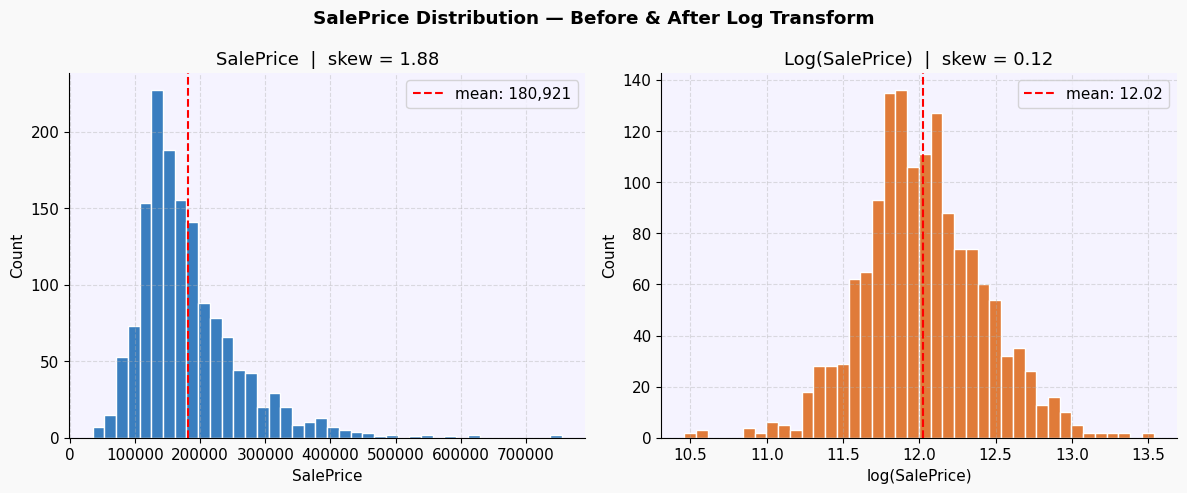

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# original saleprice
axes[0].hist(df['SalePrice'], bins=40, color='#3a7ebf', edgecolor='white')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"mean: {df['SalePrice'].mean():,.0f}")
axes[0].set_title(f"SalePrice  |  skew = {df['SalePrice'].skew():.2f}")
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')
axes[0].legend()

# log transformed
log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=40, color='#e07b39', edgecolor='white')
axes[1].axvline(log_price.mean(), color='red', linestyle='--', label=f"mean: {log_price.mean():.2f}")
axes[1].set_title(f"Log(SalePrice)  |  skew = {log_price.skew():.2f}")
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('SalePrice Distribution — Before & After Log Transform', fontweight='bold')
plt.tight_layout()
plt.savefig('w3_saleprice_dist.png', dpi=150, bbox_inches='tight')
plt.show()

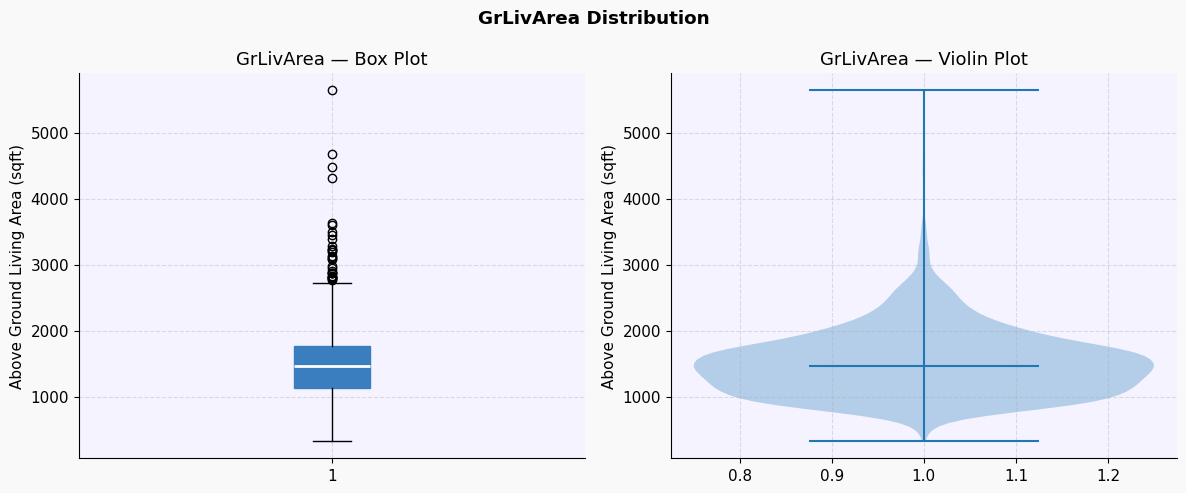

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# box plot
axes[0].boxplot(df['GrLivArea'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#3a7ebf', color='#3a7ebf'),
                medianprops=dict(color='white', linewidth=2))
axes[0].set_title('GrLivArea — Box Plot')
axes[0].set_ylabel('Above Ground Living Area (sqft)')

# violin plot
axes[1].violinplot(df['GrLivArea'].dropna(), showmedians=True)
axes[1].set_title('GrLivArea — Violin Plot')
axes[1].set_ylabel('Above Ground Living Area (sqft)')

plt.suptitle('GrLivArea Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('w3_grlivarea_dist.png', dpi=150, bbox_inches='tight')
plt.show()

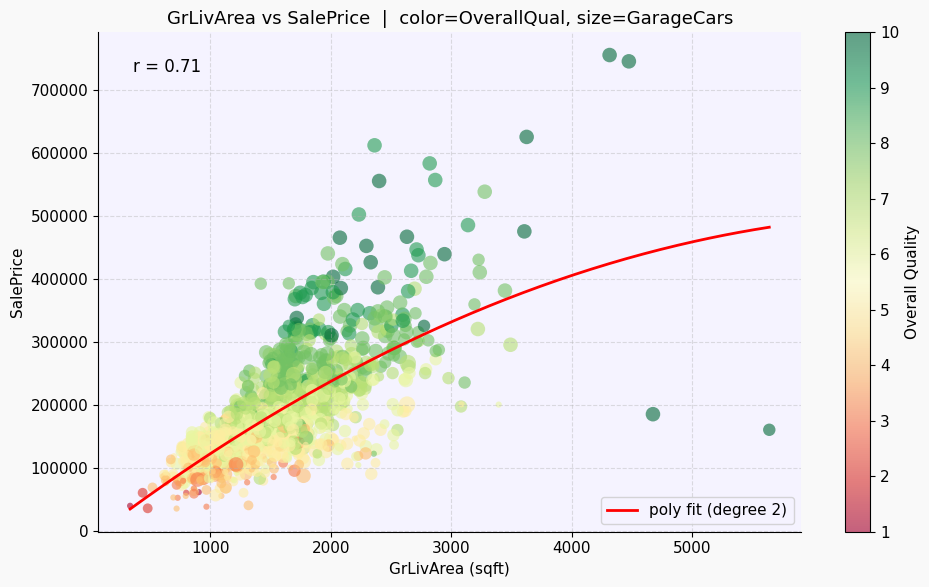

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['GrLivArea'], df['SalePrice'],
                     c=df['OverallQual'], cmap='RdYlGn',
                     s=df['GarageCars'] * 30 + 20,
                     alpha=0.6, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Quality')

# polynomial regression line
mask = df[['GrLivArea', 'SalePrice']].notna().all(axis=1)
x = df.loc[mask, 'GrLivArea']
y = df.loc[mask, 'SalePrice']
z = np.polyfit(x, y, 2)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 300)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='poly fit (degree 2)')

# pearson correlation
r, _ = stats.pearsonr(x, y)
ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=12)

ax.set_xlabel('GrLivArea (sqft)')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice  |  color=OverallQual, size=GarageCars')
ax.legend()

plt.tight_layout()
plt.savefig('w3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

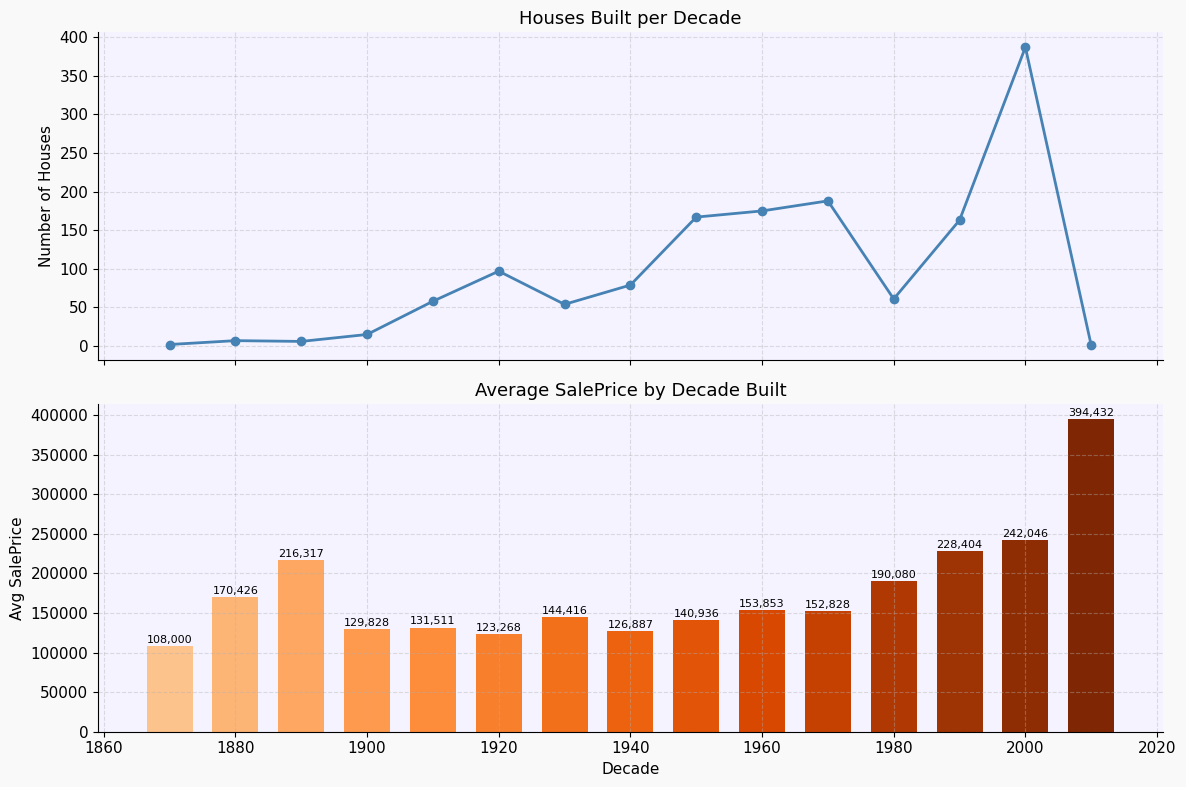

In [80]:
# bin years into decades
df['Decade'] = (df['YearBuilt'] // 10) * 10

decade_count = df.groupby('Decade')['SalePrice'].count()
decade_avg   = df.groupby('Decade')['SalePrice'].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(decade_count.index, decade_count.values, color='steelblue',
             marker='o', linewidth=2)
axes[0].set_ylabel('Number of Houses')
axes[0].set_title('Houses Built per Decade')

colors = plt.cm.Oranges(np.linspace(0.3, 1, len(decade_avg)))
bars = axes[1].bar(decade_avg.index, decade_avg.values, color=colors, width=7)
axes[1].set_ylabel('Avg SalePrice')
axes[1].set_title('Average SalePrice by Decade Built')
axes[1].set_xlabel('Decade')

# value labels on bars
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 1500,
                 f'{h:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('w3_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4762/1533863333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Neighborhood'].isin(top8)],
/tmp/ipykernel_4762/1533863333.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


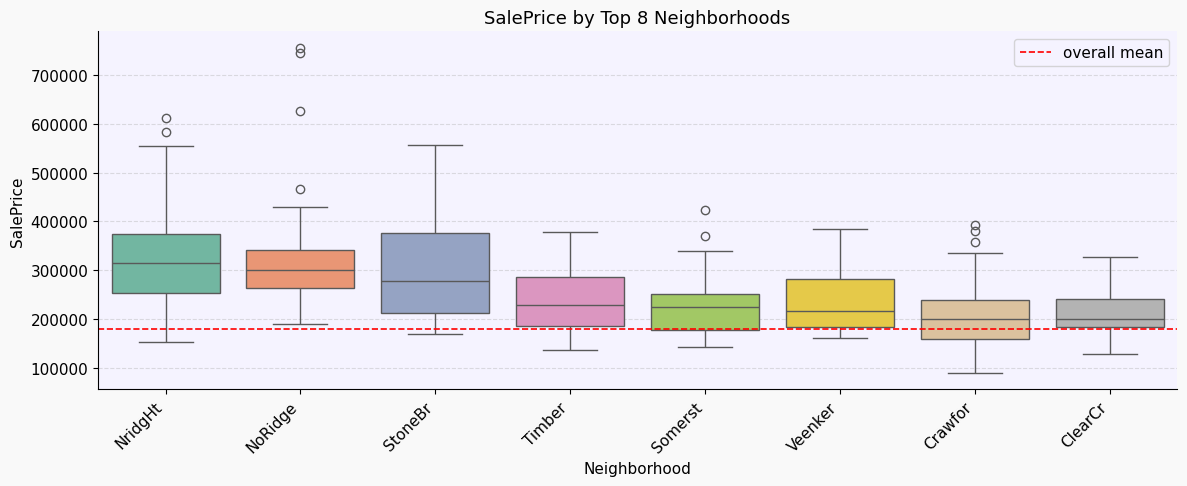

In [81]:
top8 = (df.groupby('Neighborhood')['SalePrice']
          .median()
          .sort_values(ascending=False)
          .head(8)
          .index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[df['Neighborhood'].isin(top8)],
            x='Neighborhood', y='SalePrice',
            order=top8, palette='Set2', ax=ax)

ax.axhline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=1.2, label='overall mean')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('SalePrice by Top 8 Neighborhoods')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('SalePrice')
ax.legend()

plt.tight_layout()
plt.savefig('w3_boxplot_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()

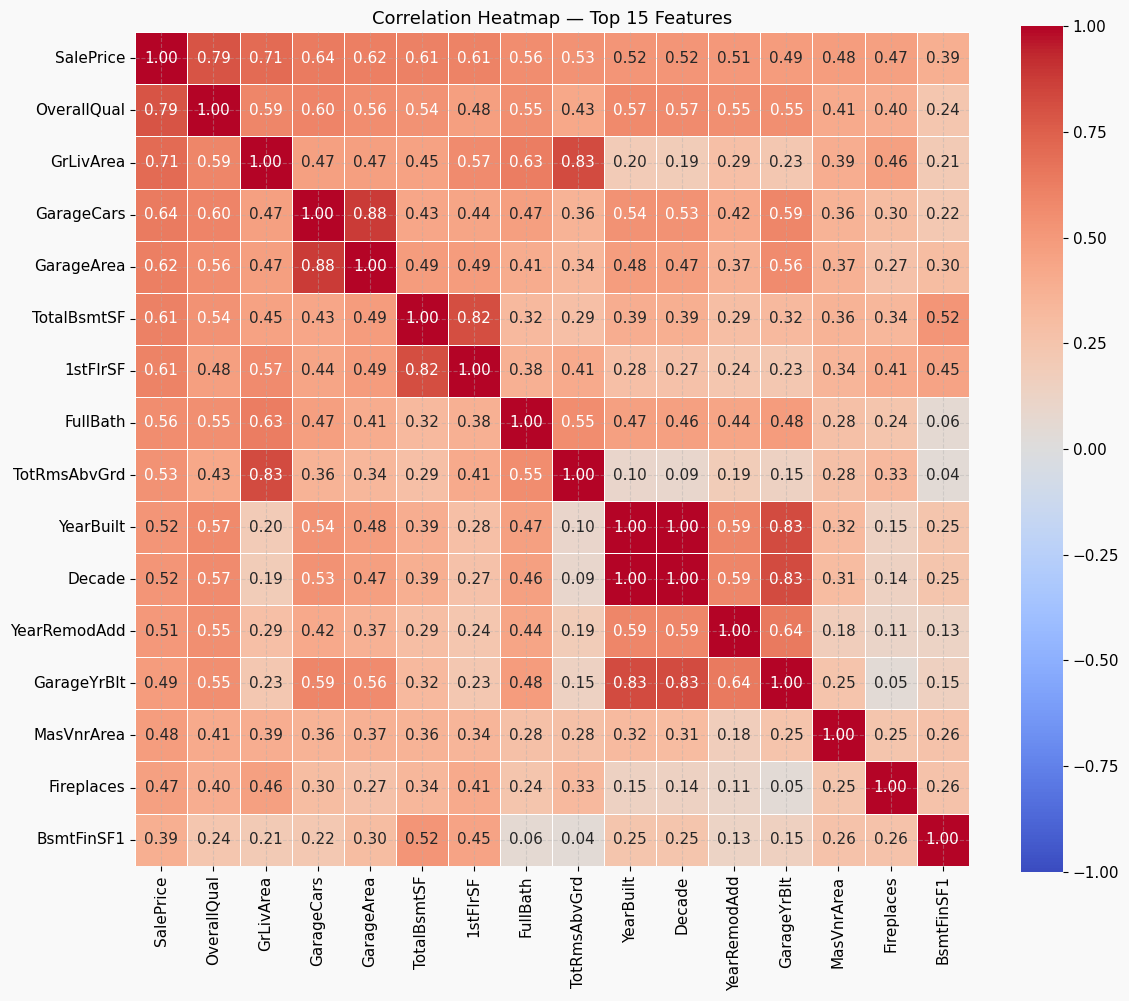

In [82]:
top15 = (df.corr(numeric_only=True)['SalePrice']
           .abs()
           .sort_values(ascending=False)
           .head(16)
           .index)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top15].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Heatmap — Top 15 Features')
plt.tight_layout()
plt.savefig('w3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

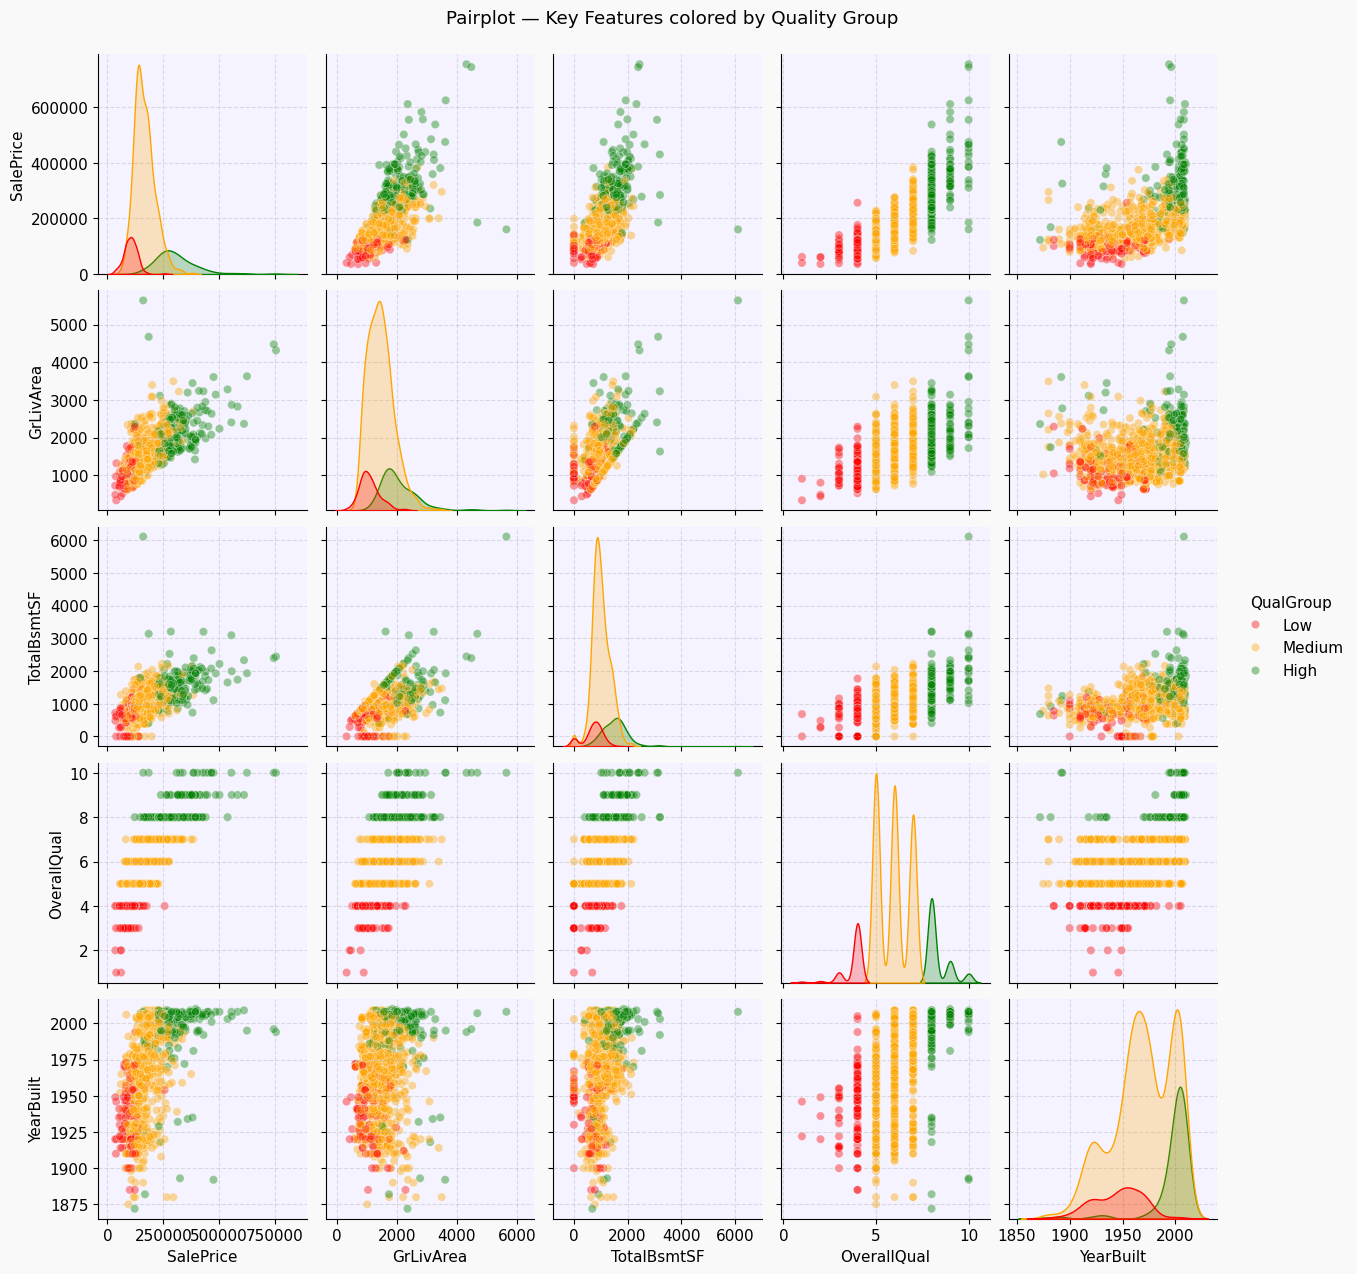

In [83]:
# bin OverallQual into 3 groups
df['QualGroup'] = pd.cut(df['OverallQual'], bins=[0,4,7,10],
                         labels=['Low','Medium','High'])

cols = ['SalePrice','GrLivArea','TotalBsmtSF','OverallQual','YearBuilt']

g = sns.pairplot(df[cols + ['QualGroup']].dropna(),
                 hue='QualGroup',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.4},
                 palette={'Low':'red','Medium':'orange','High':'green'})

g.fig.suptitle('Pairplot — Key Features colored by Quality Group', y=1.02)
g.fig.savefig('w3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

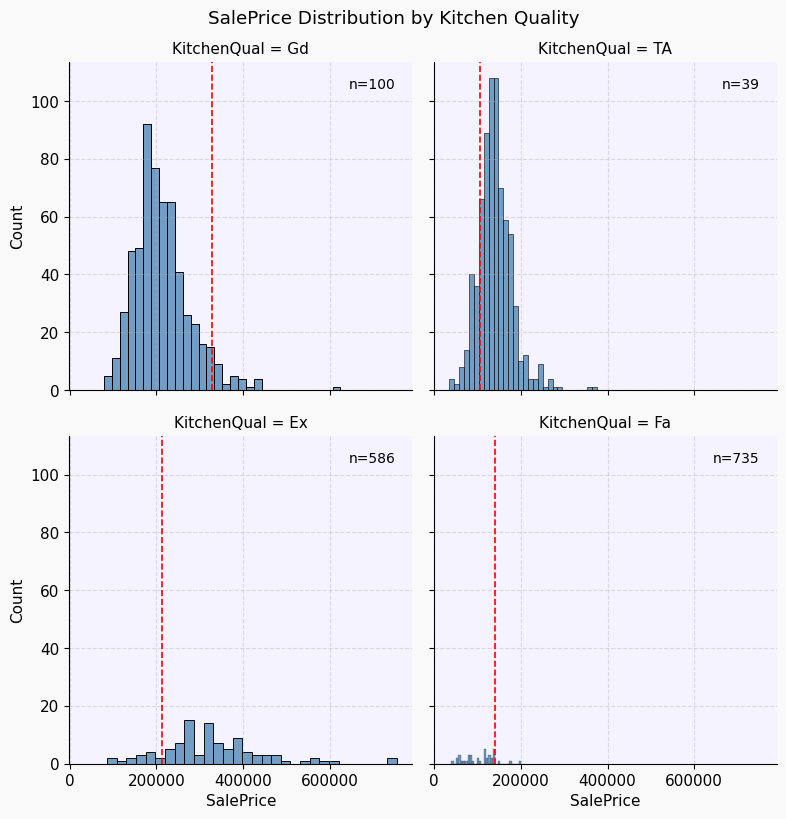

In [84]:
g = sns.FacetGrid(df.dropna(subset=['KitchenQual']),
                  col='KitchenQual', col_wrap=2, height=4)

g.map(sns.histplot, 'SalePrice', bins=30, color='steelblue')

# adding mean line and count on each facet
for ax, (key, grp) in zip(g.axes.flat,
                           df.dropna(subset=['KitchenQual']).groupby('KitchenQual')):
    ax.axvline(grp['SalePrice'].mean(), color='red',
               linestyle='--', linewidth=1.2)
    ax.text(0.95, 0.92, f'n={len(grp)}',
            transform=ax.transAxes, ha='right', fontsize=10)

g.set_titles(col_template='KitchenQual = {col_name}')
g.set_axis_labels('SalePrice', 'Count')
g.fig.suptitle('SalePrice Distribution by Kitchen Quality', y=1.02)
g.fig.savefig('w3_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalBaths'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                    df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

df['QualCond'] = df['OverallQual'] * df['OverallCond']

df['PricePerSF'] = df['SalePrice'] / df['TotalSF'].replace(0, np.nan)

df['IsNewHouse'] = (df['YearBuilt'] >= df['YrSold'] - 5).astype(int)

new_features = ['TotalSF','TotalBaths','HouseAge','RemodelAge',
                'HasRemodeled','QualCond','PricePerSF','IsNewHouse']

print(df[new_features].describe())
print()
df[new_features].head(10)

            TotalSF   TotalBaths     HouseAge   RemodelAge  HasRemodeled  \
count   1460.000000  1460.000000  1460.000000  1460.000000   1460.000000   
mean    2567.048630     2.210616    36.547945    22.950000      0.476712   
std      821.714421     0.785399    30.250152    20.640653      0.499629   
min      334.000000     1.000000     0.000000    -1.000000      0.000000   
25%     2009.500000     2.000000     8.000000     4.000000      0.000000   
50%     2474.000000     2.000000    35.000000    14.000000      0.000000   
75%     3004.000000     2.500000    54.000000    41.000000      1.000000   
max    11752.000000     6.000000   136.000000    60.000000      1.000000   

          QualCond   PricePerSF   IsNewHouse  
count  1460.000000  1460.000000  1460.000000  
mean     33.864384    69.944000     0.212329  
std       9.219624    15.397065     0.409096  
min       1.000000    13.614704     0.000000  
25%      30.000000    60.461553     0.000000  
50%      35.000000    69.679436  

,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
0,2566,3.5,5,5,0,35,81.254871,1
1,2524,2.5,31,31,0,48,71.909667,0
2,2706,3.5,7,6,1,35,82.594235,0
3,2473,2.0,91,36,1,35,56.611403,0
4,3343,3.5,8,8,0,40,74.783129,0
5,2158,2.5,16,14,1,25,66.265060,0
6,3380,3.0,3,2,1,40,90.828402,1
7,3197,3.5,36,36,0,42,62.558649,0
8,2726,2.0,77,58,1,35,47.652238,0
9,2068,2.0,69,58,1,30,57.059961,0


In [86]:
# correlation of all numeric features with SalePrice
corr_all = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)

print("Top 20 features:")
print(corr_all.drop('SalePrice').head(20).to_string())
print("\nBottom 10 features:")
print(corr_all.drop('SalePrice').tail(10).to_string())

Top 20 features:
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
HouseAge        0.523350
YearBuilt       0.522897
Decade          0.515824
RemodelAge      0.509079
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929

Bottom 10 features:
OverallCond     0.077856
MoSold          0.046432
3SsnPorch       0.044584
YrSold          0.028923
LowQualFinSF    0.025606
HasRemodeled    0.021933
Id              0.021917
MiscVal         0.021190
BsmtHalfBath    0.016844
BsmtFinSF2      0.011378


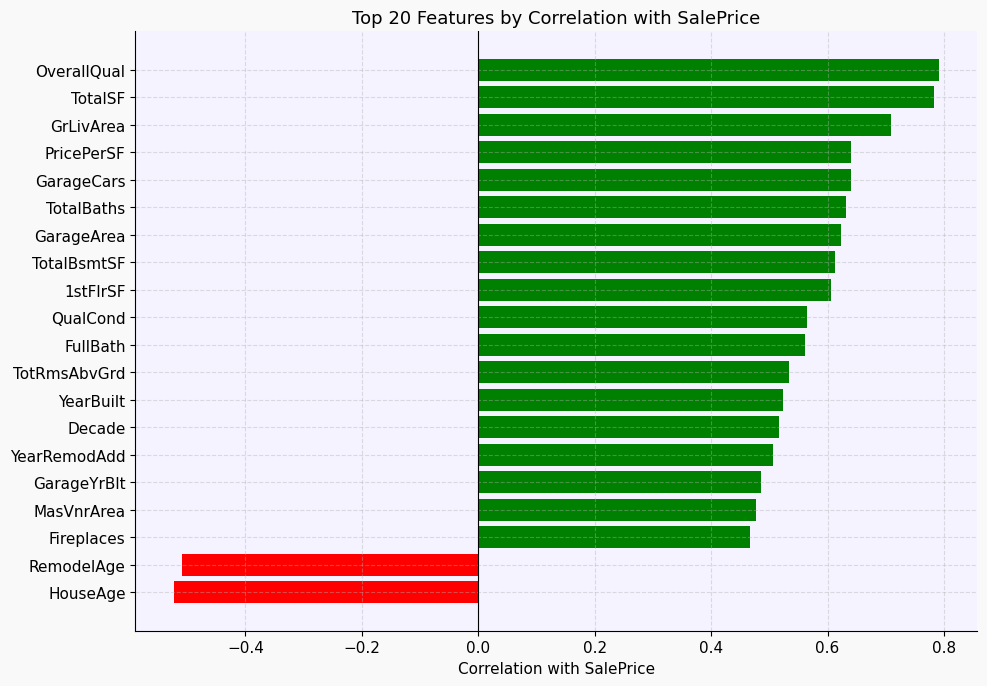

In [87]:
# top 20 by absolute correlation
corr_signed = df.corr(numeric_only=True)['SalePrice'].drop('SalePrice')
top20 = corr_signed.abs().sort_values(ascending=False).head(20).index
top20_vals = corr_signed[top20].sort_values()

colors = ['green' if v > 0 else 'red' for v in top20_vals]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_vals.index, top20_vals.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with SalePrice')
ax.set_title('Top 20 Features by Correlation with SalePrice')
plt.tight_layout()
plt.savefig('w3_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"total categorical columns: {len(cat_cols)}\n")

for col in cat_cols:
    print(f"--- {col} | unique: {df[col].nunique()} | missing: {df[col].isnull().sum()} ---")
    print(df.groupby(col)['SalePrice'].mean().sort_values(ascending=False).to_string())
    print()

total categorical columns: 43

--- MSZoning | unique: 5 | missing: 0 ---
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000

--- Street | unique: 2 | missing: 0 ---
Street
Pave    181130.538514
Grvl    130190.500000

--- Alley | unique: 2 | missing: 1369 ---
Alley
Pave    168000.585366
Grvl    122219.080000

--- LotShape | unique: 4 | missing: 0 ---
LotShape
IR2    239833.365854
IR3    216036.500000
IR1    206101.665289
Reg    164754.818378

--- LandContour | unique: 4 | missing: 0 ---
LandContour
HLS    231533.940000
Low    203661.111111
Lvl    180183.746758
Bnk    143104.079365

--- Utilities | unique: 2 | missing: 0 ---
Utilities
AllPub    180950.95682
NoSeWa    137500.00000

--- LotConfig | unique: 5 | missing: 0 ---
LotConfig
CulDSac    223854.617021
FR3        208475.000000
Corner     181623.425856
FR2        177934.574468
Inside     176938.047529

--- LandSlope | unique: 3 | missing: 0 ---
LandSlo

In [89]:
# encoding strategy for each categorical column
encoding_plan = {
    'ExterQual'   : 'label_encode',
    'ExterCond'   : 'label_encode',
    'BsmtQual'    : 'label_encode',
    'BsmtCond'    : 'label_encode',
    'HeatingQC'   : 'label_encode',
    'KitchenQual' : 'label_encode',
    'FireplaceQu' : 'label_encode',
    'GarageQual'  : 'label_encode',
    'GarageCond'  : 'label_encode',
    'PoolQC'      : 'label_encode',

    # nominal with <= 10 categories, one hot encode
    'MSZoning'    : 'onehot',
    'Street'      : 'onehot',
    'LotShape'    : 'onehot',
    'LandContour' : 'onehot',
    'LotConfig'   : 'onehot',
    'LandSlope'   : 'onehot',
    'Condition1'  : 'onehot',
    'Condition2'  : 'onehot',
    'BldgType'    : 'onehot',
    'HouseStyle'  : 'onehot',
    'RoofStyle'   : 'onehot',
    'MasVnrType'  : 'onehot',
    'Foundation'  : 'onehot',
    'BsmtExposure': 'onehot',
    'BsmtFinType1': 'onehot',
    'BsmtFinType2': 'onehot',
    'Heating'     : 'onehot',
    'CentralAir'  : 'onehot',
    'Electrical'  : 'onehot',
    'Functional'  : 'onehot',
    'GarageType'  : 'onehot',
    'GarageFinish': 'onehot',
    'PavedDrive'  : 'onehot',
    'Fence'       : 'onehot',
    'SaleType'    : 'onehot',
    'SaleCondition': 'onehot',

    # nominal with > 10 categories, frequency encode
    'Neighborhood': 'frequency_encode',
    'Exterior1st' : 'frequency_encode',
    'Exterior2nd' : 'frequency_encode',
    'RoofMatl'    : 'frequency_encode',
    'MiscFeature' : 'frequency_encode',
    'Alley'       : 'frequency_encode',
}

import pandas as pd
plan_df = pd.DataFrame(list(encoding_plan.items()), columns=['Column', 'Strategy'])
print(plan_df.groupby('Strategy')['Column'].count())
print()
print(plan_df.to_string(index=False))

Strategy
frequency_encode     6
label_encode        10
onehot              26
Name: Column, dtype: int64

       Column         Strategy
    ExterQual     label_encode
    ExterCond     label_encode
     BsmtQual     label_encode
     BsmtCond     label_encode
    HeatingQC     label_encode
  KitchenQual     label_encode
  FireplaceQu     label_encode
   GarageQual     label_encode
   GarageCond     label_encode
       PoolQC     label_encode
     MSZoning           onehot
       Street           onehot
     LotShape           onehot
  LandContour           onehot
    LotConfig           onehot
    LandSlope           onehot
   Condition1           onehot
   Condition2           onehot
     BldgType           onehot
   HouseStyle           onehot
    RoofStyle           onehot
   MasVnrType           onehot
   Foundation           onehot
 BsmtExposure           onehot
 BsmtFinType1           onehot
 BsmtFinType2           onehot
      Heating           onehot
   CentralAir           on

In [90]:
print("shape before encoding:", df.shape)

#  (a) Label Encoding for quality columns
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    df[col] = df[col].fillna('NA').map(quality_map)

#  (b) One-Hot Encoding for nominal columns <= 10 categories
onehot_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig',
               'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
               'RoofStyle', 'MasVnrType', 'Foundation', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir',
               'Electrical', 'Functional', 'GarageType', 'GarageFinish',
               'PavedDrive', 'Fence', 'SaleType', 'SaleCondition']

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

#  (c) Frequency Encoding for high cardinality columns
freq_cols = ['Neighborhood', 'Exterior1st', 'Exterior2nd',
             'RoofMatl', 'MiscFeature', 'Alley']

for col in freq_cols:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

remaining = df.select_dtypes(include='object').columns.tolist()
print("remaining object columns:", remaining)
print("shape after encoding:", df.shape)

shape before encoding: (1460, 91)
remaining object columns: ['Utilities']
shape after encoding: (1460, 174)


In [91]:
df.drop(columns=['Utilities'], inplace=True)

remaining = df.select_dtypes(include='object').columns.tolist()
print("remaining object columns:", remaining)
print("final shape:", df.shape)

remaining object columns: []
final shape: (1460, 173)


In [92]:
X = df.drop('SalePrice', axis=1).select_dtypes(include='number')
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ss  = StandardScaler()
mm  = MinMaxScaler()
rob = RobustScaler()

X_train_ss  = ss.fit_transform(X_train)
X_test_ss   = ss.transform(X_test)

X_train_mm  = mm.fit_transform(X_train)
X_test_mm   = mm.transform(X_test)

X_train_rob = rob.fit_transform(X_train)
X_test_rob  = rob.transform(X_test)

check_cols = ['GrLivArea', 'TotalSF', 'HouseAge']
col_idx = [X_train.columns.get_loc(c) for c in check_cols]

print(f"{'Feature':<15} {'Original Mean':>15} {'Original Std':>13} {'SS Mean':>10} {'SS Std':>10} {'MM Mean':>10} {'MM Std':>10}")
print("-" * 90)
for i, col in zip(col_idx, check_cols):
    print(f"{col:<15} {X_train.iloc[:,i].mean():>15.2f} {X_train.iloc[:,i].std():>13.2f}"
          f" {X_train_ss[:,i].mean():>10.3f} {X_train_ss[:,i].std():>10.3f}"
          f" {X_train_mm[:,i].mean():>10.3f} {X_train_mm[:,i].std():>10.3f}")

Feature           Original Mean  Original Std    SS Mean     SS Std    MM Mean     MM Std
------------------------------------------------------------------------------------------
GrLivArea               1527.40        524.43     -0.000      1.000      0.225      0.099
TotalSF                 2583.48        821.31      0.000      1.000      0.197      0.072
HouseAge                  36.85         30.70      0.000      1.000      0.271      0.226


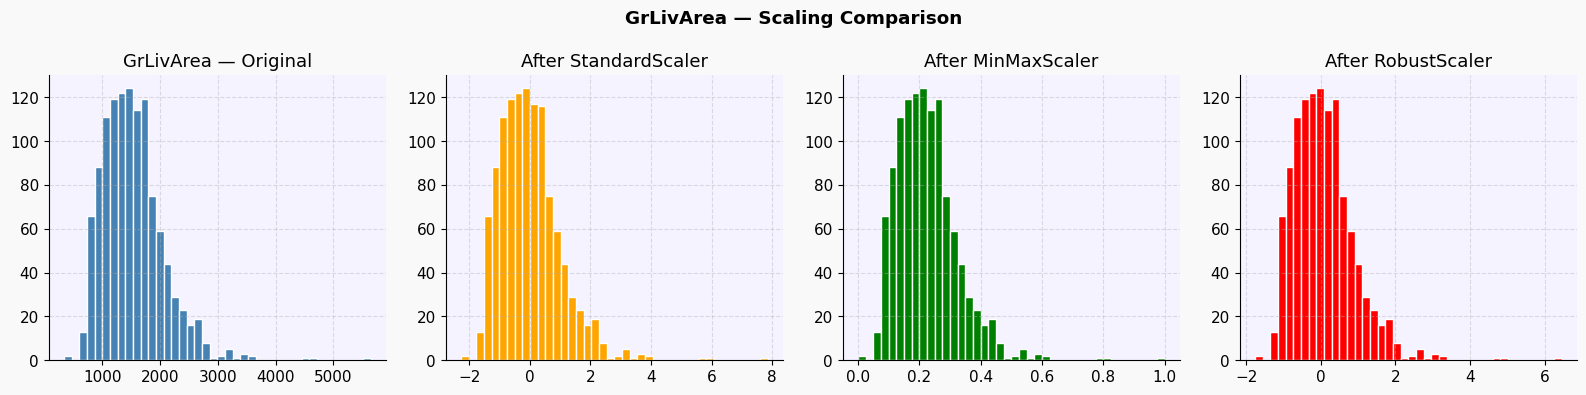

In [93]:
grlivarea_idx = X_train.columns.get_loc('GrLivArea')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(X_train['GrLivArea'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('GrLivArea — Original')

axes[1].hist(X_train_ss[:, grlivarea_idx], bins=40, color='orange', edgecolor='white')
axes[1].set_title('After StandardScaler')

axes[2].hist(X_train_mm[:, grlivarea_idx], bins=40, color='green', edgecolor='white')
axes[2].set_title('After MinMaxScaler')

axes[3].hist(X_train_rob[:, grlivarea_idx], bins=40, color='red', edgecolor='white')
axes[3].set_title('After RobustScaler')

plt.suptitle('GrLivArea — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('w3_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
# computing skewness for all numeric columns
skew_vals = df.select_dtypes(include='number').skew().abs().sort_values(ascending=False)

def skew_label(s):
    if s < 0.5:   return 'Normal'
    elif s < 1:   return 'Moderate'
    elif s < 2:   return 'High'
    else:         return 'Very High'

skew_df = pd.DataFrame({'skewness': skew_vals})
skew_df['severity'] = skew_df['skewness'].apply(skew_label)

print(skew_df.to_string())
print(f"\ntotal features with |skew| > 1: {(skew_vals > 1).sum()}")
print(f"percentage highly skewed: {(skew_vals > 1).sum() / len(skew_vals) * 100:.1f}%")

                skewness   severity
MiscVal        24.476794  Very High
PoolQC         15.958567  Very High
PoolArea       14.828374  Very High
LotArea        12.207688  Very High
3SsnPorch      10.304342  Very High
LowQualFinSF    9.011341  Very High
RoofMatl        7.299489  Very High
KitchenAbvGr    4.488397  Very High
BsmtFinSF2      4.255261  Very High
ScreenPorch     4.122214  Very High
BsmtHalfBath    4.103403  Very High
BsmtCond        3.701033  Very High
GarageCond      3.331900  Very High
GarageQual      3.228583  Very High
EnclosedPorch   3.089872  Very High
MiscFeature     2.892444  Very High
MasVnrArea      2.669084  Very High
OpenPorchSF     2.364342  Very High
LotFrontage     2.163569  Very High
SalePrice       1.882876       High
TotalSF         1.776700       High
BsmtFinSF1      1.685503       High
WoodDeckSF      1.541376       High
TotalBsmtSF     1.524255       High
IsNewHouse      1.408303       High
MSSubClass      1.407657       High
ExterCond       1.397219    

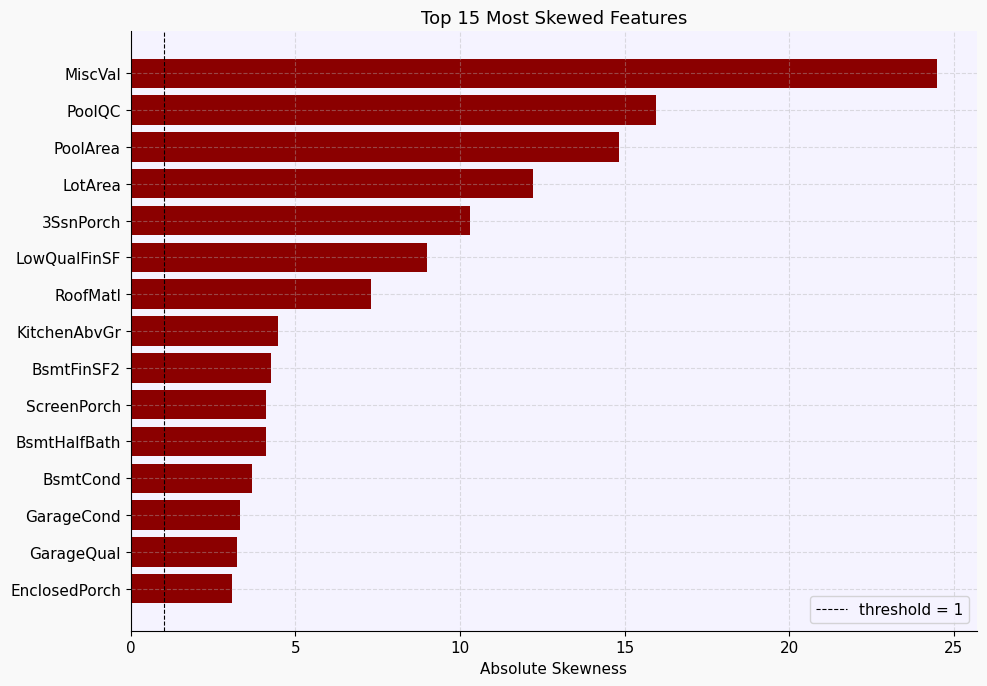

In [95]:
top15_skew = skew_df.head(15)

color_map = {'Normal': 'green', 'Moderate': 'orange',
             'High': 'red', 'Very High': 'darkred'}
colors = top15_skew['severity'].map(color_map)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_skew.index[::-1], top15_skew['skewness'][::-1], color=colors[::-1])
ax.set_xlabel('Absolute Skewness')
ax.set_title('Top 15 Most Skewed Features')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8, label='threshold = 1')
ax.legend()
plt.tight_layout()
plt.savefig('w3_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# for getting all numeric columns with |skew| > 0.75 excluding SalePrice
num_cols_now = df.select_dtypes(include='number').columns.tolist()
skew_vals2 = df[num_cols_now].skew().abs()
skewed_cols = skew_vals2[skew_vals2 > 0.75].index.tolist()
if 'SalePrice' in skewed_cols:
    skewed_cols.remove('SalePrice')

print(f"columns to transform: {len(skewed_cols)}")

# applying log1p to all skewed features
for col in skewed_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

print("done — log1p applied")

columns to transform: 33
done — log1p applied


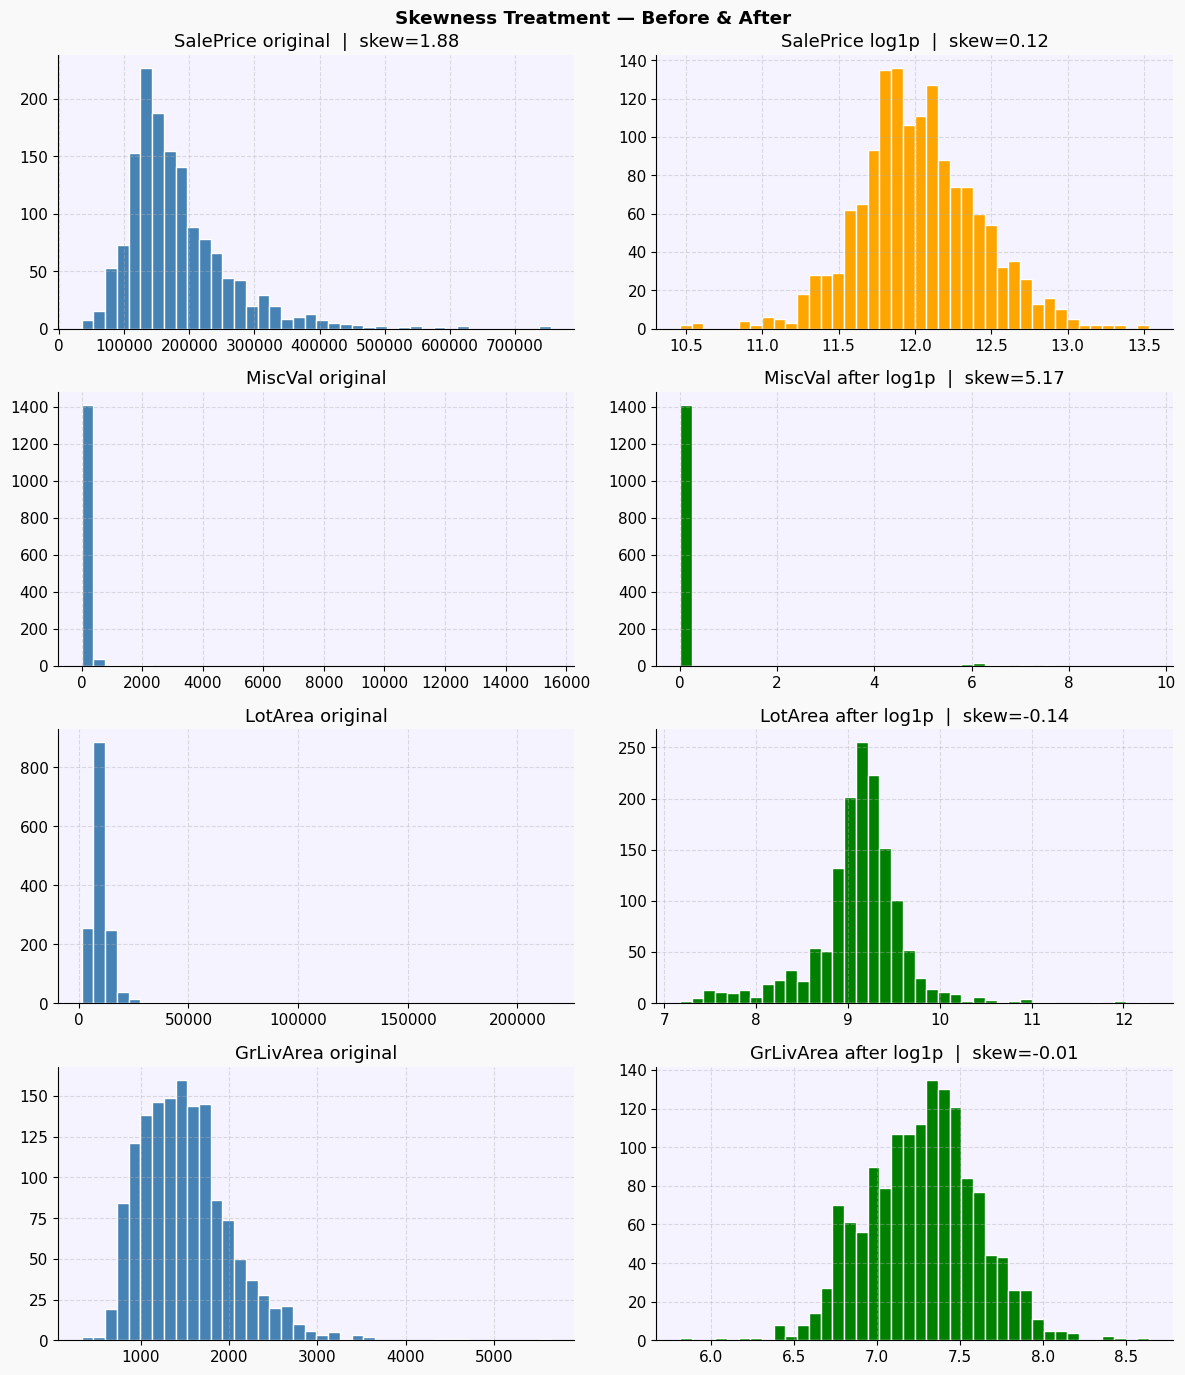


SalePrice skew before: 1.88
SalePrice log1p skew : 0.12
SalePrice sqrt skew  : 0.94
SalePrice box-cox skew: -0.01

best transformation for SalePrice: log1p


In [97]:
sp = df['SalePrice']
sp_log  = np.log1p(sp)
sp_sqrt = np.sqrt(sp)
sp_bc, _ = boxcox(sp + 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

# SalePrice before/after
axes[0,0].hist(sp, bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title(f'SalePrice original  |  skew={sp.skew():.2f}')

axes[0,1].hist(sp_log, bins=40, color='orange', edgecolor='white')
axes[0,1].set_title(f'SalePrice log1p  |  skew={sp_log.skew():.2f}')

other = ['MiscVal', 'LotArea', 'GrLivArea']
colors_before = ['steelblue', 'steelblue', 'steelblue']
colors_after  = ['green', 'green', 'green']

for i, col in enumerate(other):
    original = np.expm1(df[col])
    transformed = df[col]
    axes[i+1, 0].hist(original, bins=40, color='steelblue', edgecolor='white')
    axes[i+1, 0].set_title(f'{col} original')
    axes[i+1, 1].hist(transformed, bins=40, color='green', edgecolor='white')
    axes[i+1, 1].set_title(f'{col} after log1p  |  skew={transformed.skew():.2f}')

plt.suptitle('Skewness Treatment — Before & After', fontweight='bold')
plt.tight_layout()
plt.savefig('w3_skewness_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

df['SalePrice_transformed'] = sp_log
print(f"\nSalePrice skew before: {sp.skew():.2f}")
print(f"SalePrice log1p skew : {sp_log.skew():.2f}")
print(f"SalePrice sqrt skew  : {sp_sqrt.skew():.2f}")
print(f"SalePrice box-cox skew: {pd.Series(sp_bc).skew():.2f}")
print("\nbest transformation for SalePrice: log1p")

In [98]:
X = df.drop(['SalePrice', 'SalePrice_transformed'], axis=1).select_dtypes(include='number')
y = df['SalePrice']

print(f"starting features: {X.shape[1]}")

# (a) top 30 by correlation with SalePrice
corr = X.corrwith(y).abs().sort_values(ascending=False)
top30 = corr.head(30).index.tolist()
X = X[top30]
print(f"after correlation filter: {X.shape[1]}")

# (b) variance threshold
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
X = X.loc[:, vt.get_support()]
print(f"after variance threshold: {X.shape[1]}")

# (c) drop multicollinear features (r > 0.95)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"multicollinear columns to drop: {to_drop}")
X = X.drop(columns=to_drop)
print(f"after multicollinearity filter: {X.shape[1]}")

final_corr = X.corrwith(y).abs().sort_values(ascending=False)
print("\nfinal selected features:")
print(final_corr.to_string())
print(f"\noriginal features: {df.shape[1]}")
print(f"final features   : {X.shape[1]}")

starting features: 62
after correlation filter: 30
after variance threshold: 29
multicollinear columns to drop: ['YearBuilt', 'Decade', 'YearRemodAdd']
after multicollinearity filter: 26

final selected features:
OverallQual     0.790982
TotalSF         0.761613
GrLivArea       0.695147
ExterQual       0.673241
KitchenQual     0.659600
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
1stFlrSF        0.591299
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
HouseAge        0.523350
FireplaceQu     0.520438
RemodelAge      0.509079
GarageYrBlt     0.486362
Fireplaces      0.466929
BsmtQual        0.453622
IsNewHouse      0.433543
OpenPorchSF     0.429970
HeatingQC       0.427649
MasVnrArea      0.410944
LotArea         0.388528
LotFrontage     0.349480
TotalBsmtSF     0.325883

original features: 174
final features   : 26


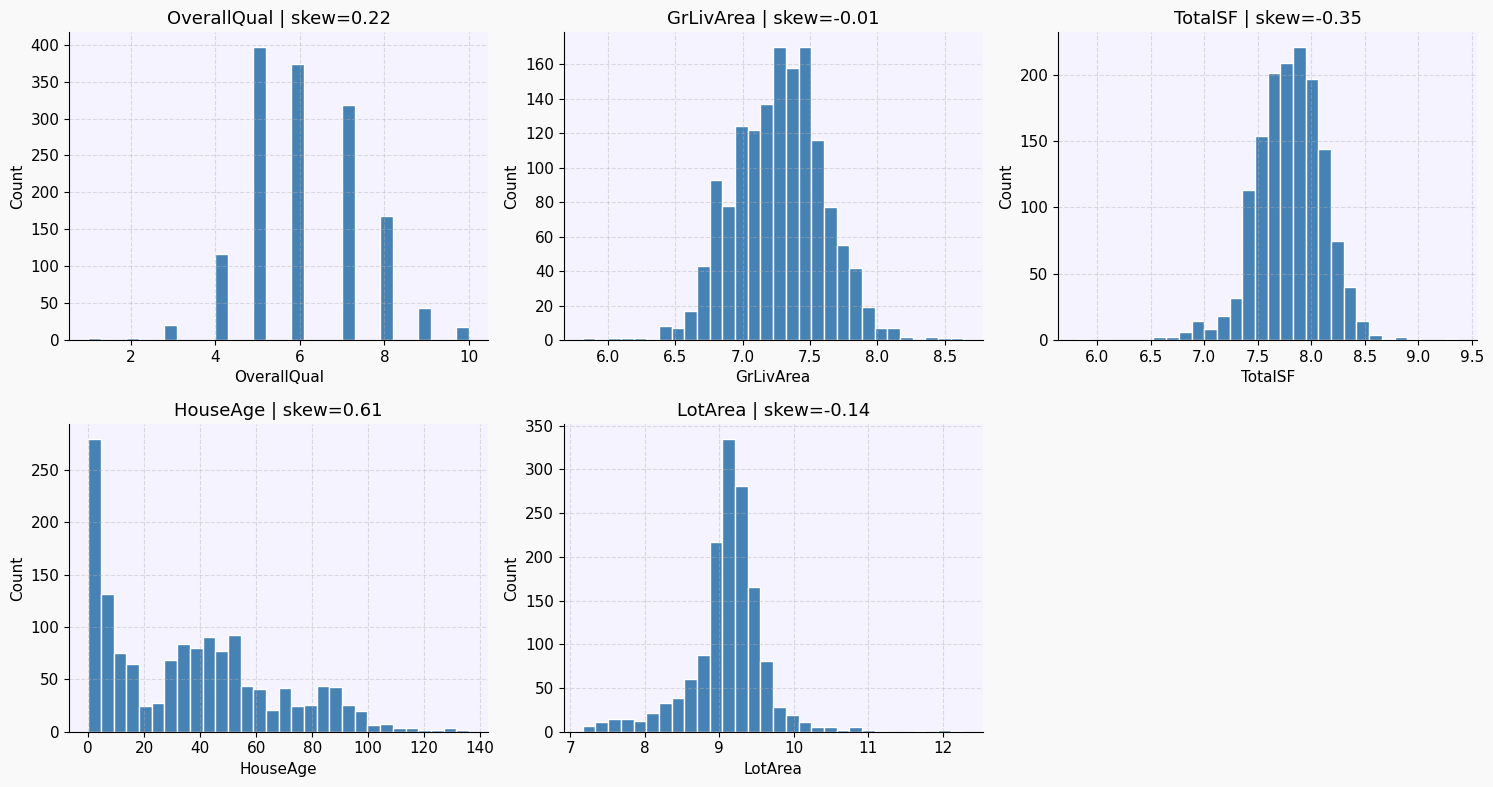

encoding map: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64

scaled train mean: [ 0. -0.  0.]
scaled train std : [1. 1. 1.]


In [99]:
def visualize_distributions(df, cols, n_cols=3):
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        skew = df[col].skew()
        axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col} | skew={skew:.2f}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


def encode_quality_column(series, quality_map=None):
    if quality_map is None:
        quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
    encoded = series.fillna('NA').map(quality_map)
    return encoded, quality_map


def full_scaling_pipeline(X_train, X_test, method='standard'):
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError("method must be 'standard', 'minmax', or 'robust'")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

# function 1
visualize_distributions(df, ['OverallQual', 'GrLivArea', 'TotalSF', 'HouseAge', 'LotArea'], n_cols=3)

# function 2
encoded, mapping = encode_quality_column(df['KitchenQual'].map({5:'Ex',4:'Gd',3:'TA',2:'Fa',1:'Po'}).fillna('NA'))
print("encoding map:", mapping)
print(encoded.value_counts())

# function 3
X_temp = df[['GrLivArea', 'TotalSF', 'HouseAge']].fillna(0)
X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y, test_size=0.2, random_state=42)
tr_scaled, te_scaled, fitted_scaler = full_scaling_pipeline(X_tr, X_te, method='standard')
print(f"\nscaled train mean: {tr_scaled.mean(axis=0).round(3)}")
print(f"scaled train std : {tr_scaled.std(axis=0).round(3)}")

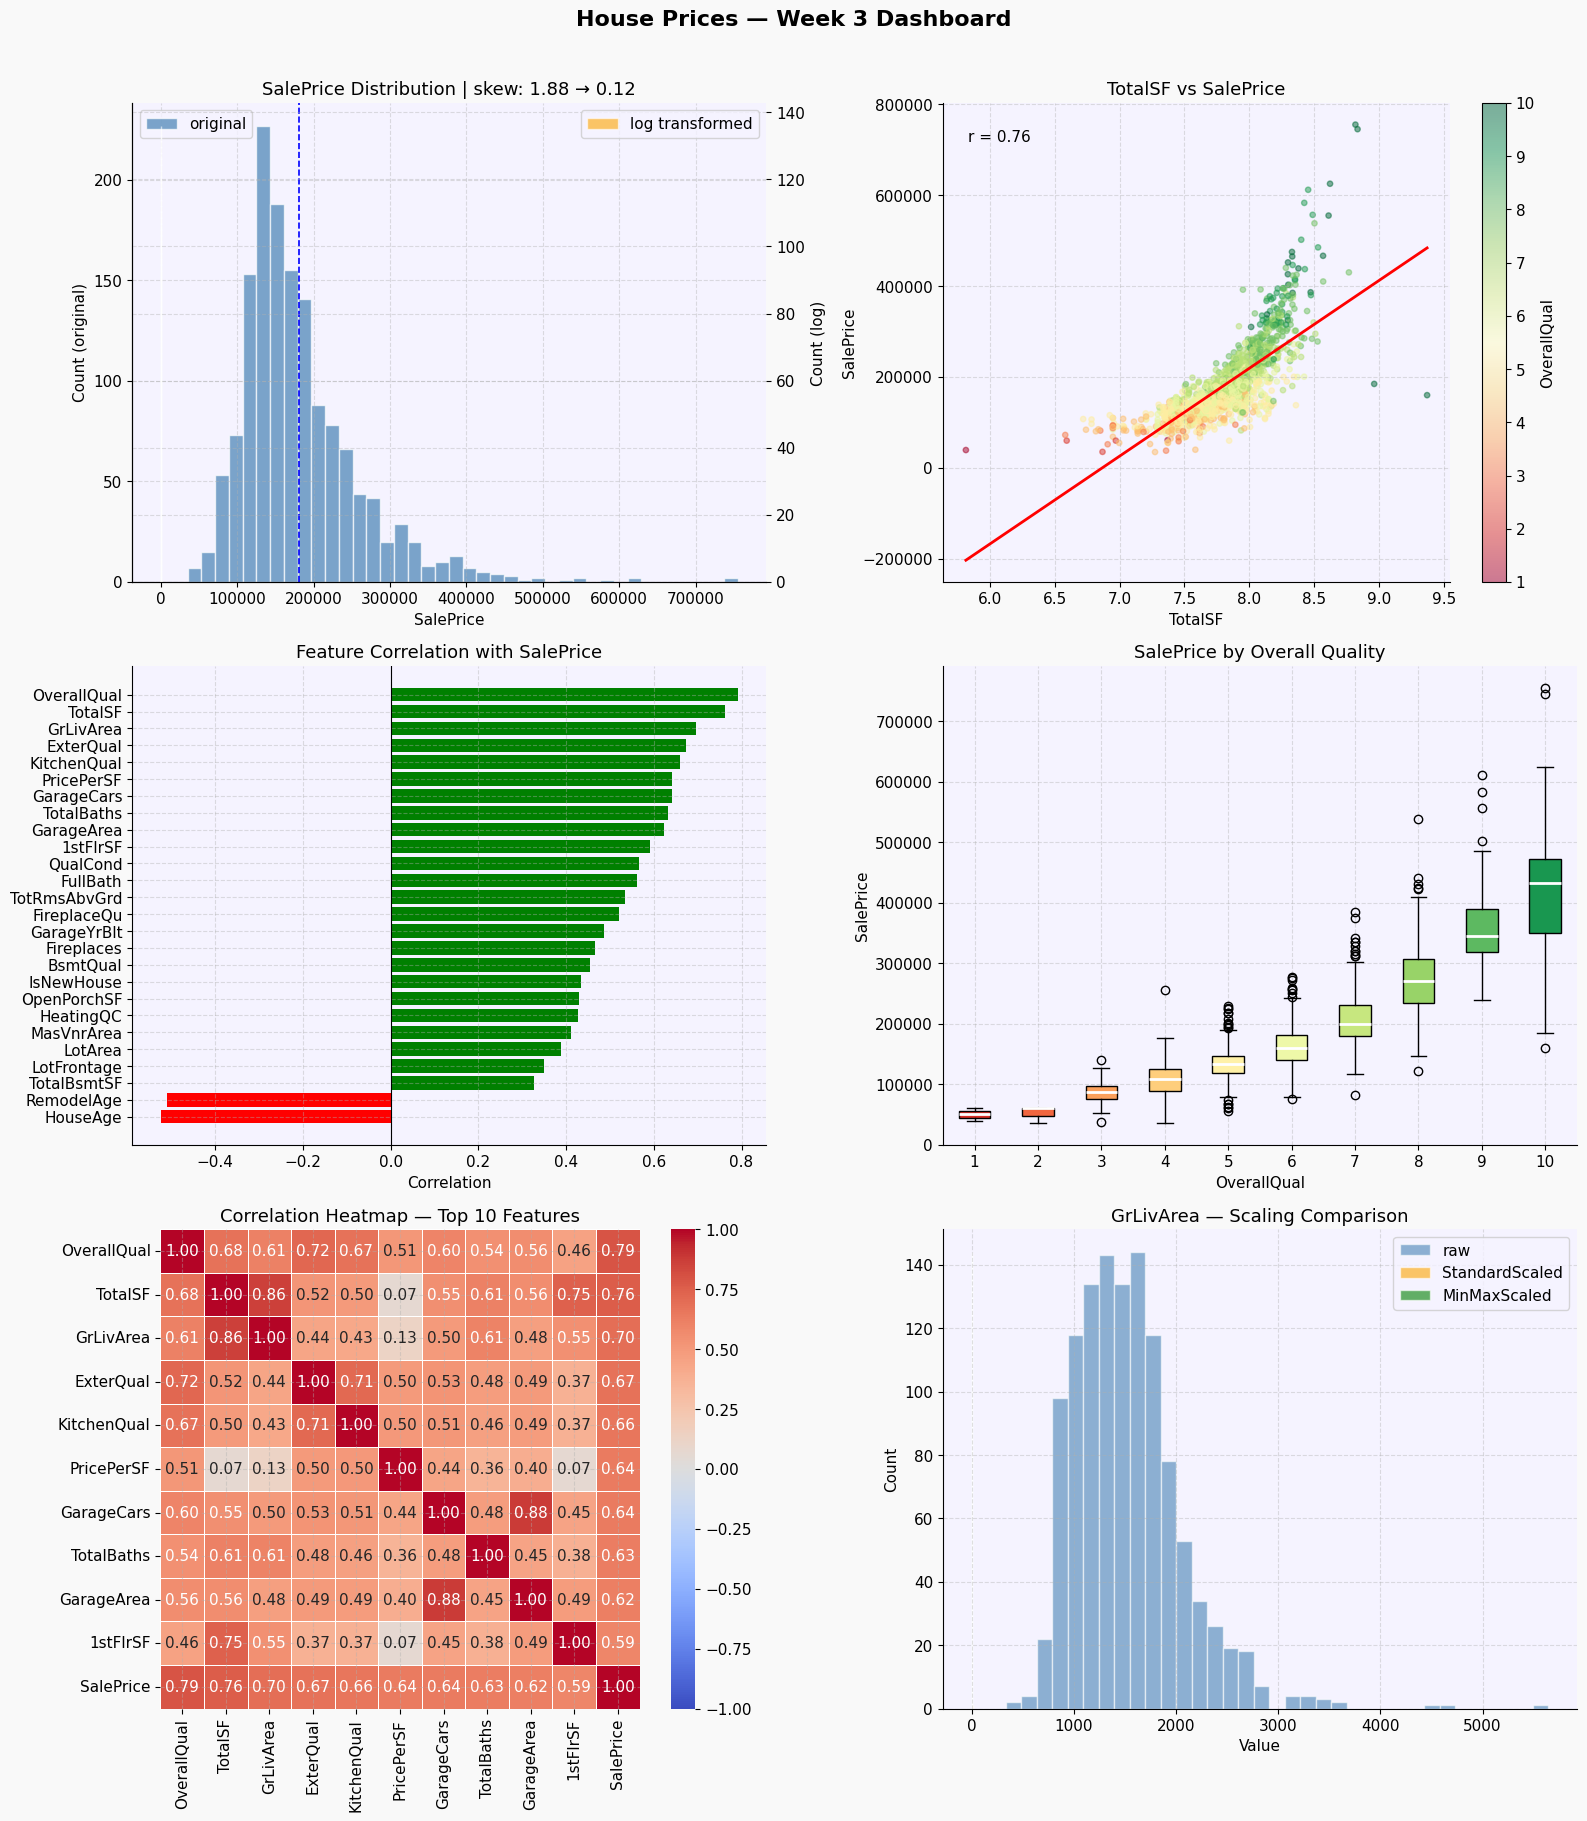

In [100]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('House Prices — Week 3 Dashboard', fontsize=16, fontweight='bold', y=1.01)

#  Chart 1: SalePrice before & after log transform
sp_orig = df['SalePrice']
sp_log  = df['SalePrice_transformed']

axes[0,0].hist(sp_orig, bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='original')
ax2 = axes[0,0].twinx()
ax2.hist(sp_log, bins=40, color='orange', edgecolor='white', alpha=0.6, label='log transformed')
axes[0,0].axvline(sp_orig.mean(), color='blue', linestyle='--', linewidth=1.2)
axes[0,0].set_title(f'SalePrice Distribution | skew: {sp_orig.skew():.2f} → {sp_log.skew():.2f}')
axes[0,0].set_xlabel('SalePrice')
axes[0,0].set_ylabel('Count (original)')
ax2.set_ylabel('Count (log)')
axes[0,0].legend(loc='upper left')
ax2.legend(loc='upper right')

#  Chart 2: TotalSF vs SalePrice colored by OverallQual
sc = axes[0,1].scatter(df['TotalSF'], df['SalePrice'],
                       c=df['OverallQual'], cmap='RdYlGn',
                       alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[0,1], label='OverallQual')
# regression line
mask = df[['TotalSF','SalePrice']].notna().all(axis=1)
z = np.polyfit(df.loc[mask,'TotalSF'], df.loc[mask,'SalePrice'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['TotalSF'].min(), df['TotalSF'].max(), 200)
axes[0,1].plot(x_line, p(x_line), color='red', linewidth=2)
r, _ = stats.pearsonr(df.loc[mask,'TotalSF'], df.loc[mask,'SalePrice'])
axes[0,1].annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)
axes[0,1].set_title('TotalSF vs SalePrice')
axes[0,1].set_xlabel('TotalSF')
axes[0,1].set_ylabel('SalePrice')

#  Chart 3: Top 15 features by correlation
final_corr_signed = df[X.columns].corrwith(df['SalePrice']).sort_values()
colors = ['green' if v > 0 else 'red' for v in final_corr_signed]
axes[1,0].barh(final_corr_signed.index, final_corr_signed.values, color=colors)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Feature Correlation with SalePrice')
axes[1,0].set_xlabel('Correlation')

#  Chart 4: SalePrice by OverallQual
qual_data = [df[df['OverallQual'] == q]['SalePrice'].dropna()
             for q in sorted(df['OverallQual'].unique())]
bp = axes[1,1].boxplot(qual_data, patch_artist=True,
                       medianprops=dict(color='white', linewidth=2))
colors_box = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(qual_data)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[1,1].set_xticklabels(sorted(df['OverallQual'].unique()))
axes[1,1].set_title('SalePrice by Overall Quality')
axes[1,1].set_xlabel('OverallQual')
axes[1,1].set_ylabel('SalePrice')

#  Chart 5: Correlation heatmap top 10 features
top10 = X.corrwith(df['SalePrice']).abs().sort_values(ascending=False).head(10).index.tolist()
sns.heatmap(df[top10 + ['SalePrice']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=axes[2,0])
axes[2,0].set_title('Correlation Heatmap — Top 10 Features')

#  Chart 6: Scaling comparison for GrLivArea
grlivarea_idx = X_train.columns.get_loc('GrLivArea')
axes[2,1].hist(X_train['GrLivArea'], bins=35, color='steelblue',
               edgecolor='white', alpha=0.6, label='raw')
axes[2,1].hist(X_train_ss[:, grlivarea_idx], bins=35, color='orange',
               edgecolor='white', alpha=0.6, label='StandardScaled')
axes[2,1].hist(X_train_mm[:, grlivarea_idx], bins=35, color='green',
               edgecolor='white', alpha=0.6, label='MinMaxScaled')
axes[2,1].set_title('GrLivArea — Scaling Comparison')
axes[2,1].set_xlabel('Value')
axes[2,1].set_ylabel('Count')
axes[2,1].legend()

plt.tight_layout()
plt.savefig('week3_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


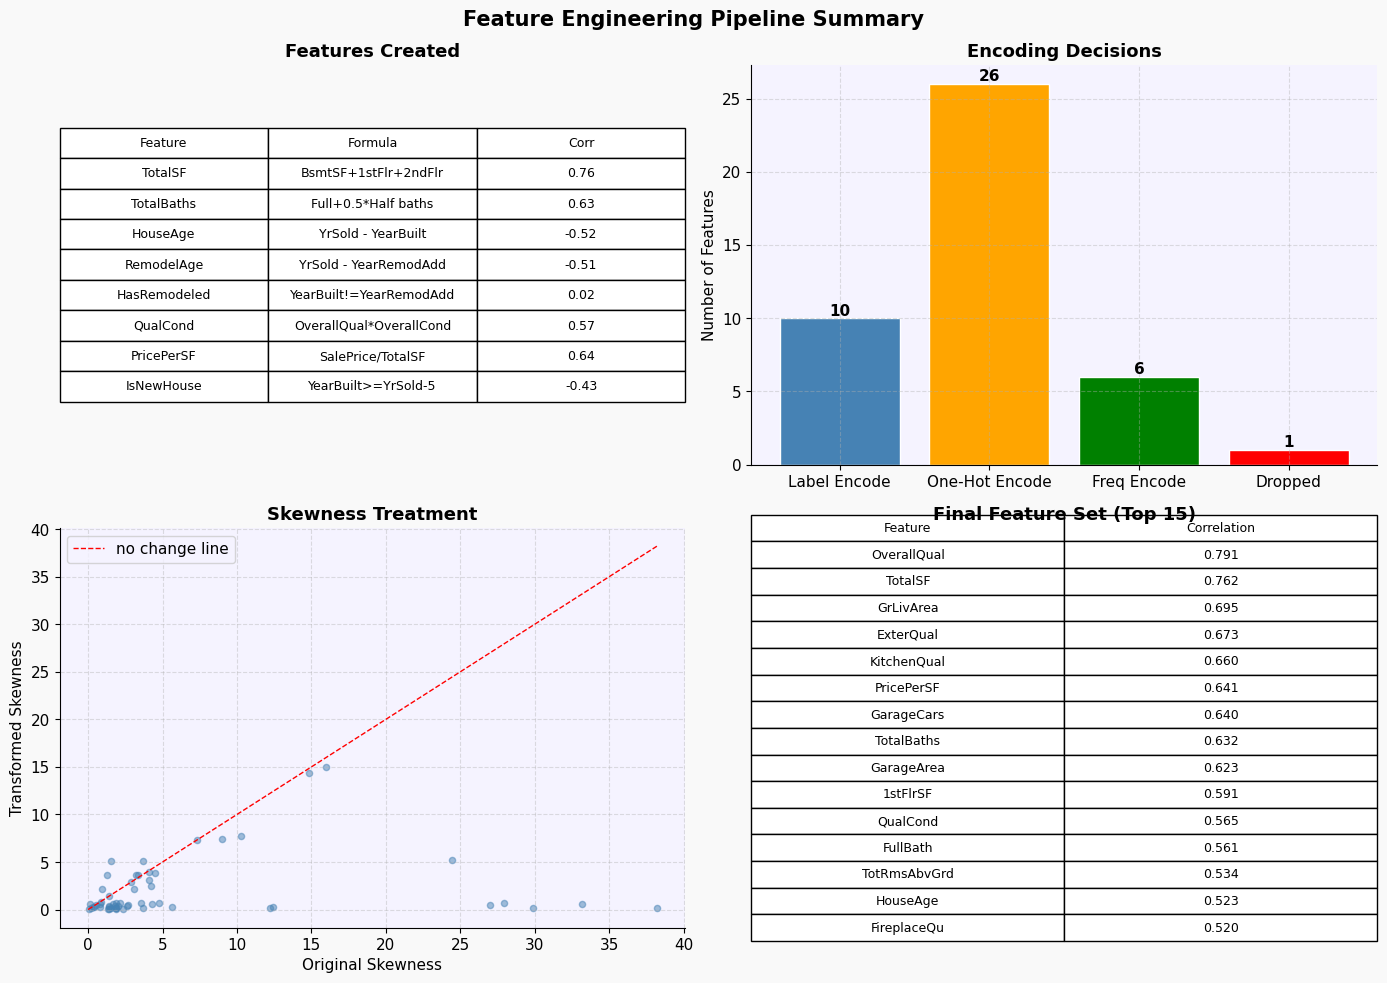

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering Pipeline Summary', fontsize=15, fontweight='bold')

# Panel 1: engineered features table
axes[0,0].axis('off')
feat_data = [
    ['TotalSF',       'BsmtSF+1stFlr+2ndFlr',  '0.76'],
    ['TotalBaths',    'Full+0.5*Half baths',    '0.63'],
    ['HouseAge',      'YrSold - YearBuilt',     '-0.52'],
    ['RemodelAge',    'YrSold - YearRemodAdd',  '-0.51'],
    ['HasRemodeled',  'YearBuilt!=YearRemodAdd','0.02'],
    ['QualCond',      'OverallQual*OverallCond', '0.57'],
    ['PricePerSF',    'SalePrice/TotalSF',      '0.64'],
    ['IsNewHouse',    'YearBuilt>=YrSold-5',    '-0.43'],
]
table = axes[0,0].table(
    cellText=feat_data,
    colLabels=['Feature', 'Formula', 'Corr'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
axes[0,0].set_title('Features Created', fontweight='bold')

#  Panel 2: encoding strategy counts
strategies = ['Label Encode', 'One-Hot Encode', 'Freq Encode', 'Dropped']
counts      = [10, 26, 6, 1]
colors      = ['steelblue', 'orange', 'green', 'red']
axes[0,1].bar(strategies, counts, color=colors, edgecolor='white')
axes[0,1].set_title('Encoding Decisions', fontweight='bold')
axes[0,1].set_ylabel('Number of Features')
for i, v in enumerate(counts):
    axes[0,1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

#  Panel 3: original vs transformed skewness scatter
num_cols_check = df.select_dtypes(include='number').columns
orig_skew = pd.Series({c: np.expm1(df[c]).skew()
                       if df[c].min() >= 0 else df[c].skew()
                       for c in num_cols_check}).abs()
trans_skew = df[num_cols_check].skew().abs()

axes[1,0].scatter(orig_skew, trans_skew, alpha=0.5, color='steelblue', s=20)
axes[1,0].plot([0, orig_skew.max()], [0, orig_skew.max()],
               color='red', linestyle='--', linewidth=1, label='no change line')
axes[1,0].set_xlabel('Original Skewness')
axes[1,0].set_ylabel('Transformed Skewness')
axes[1,0].set_title('Skewness Treatment', fontweight='bold')
axes[1,0].legend()

# Panel 4: final feature set table
axes[1,1].axis('off')
final_corr2 = X.corrwith(df['SalePrice']).abs().sort_values(ascending=False).head(15)
feat_table  = [[f, f'{v:.3f}'] for f, v in final_corr2.items()]
table2 = axes[1,1].table(
    cellText=feat_table,
    colLabels=['Feature', 'Correlation'],
    loc='center', cellLoc='center'
)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.4)
axes[1,1].set_title('Final Feature Set (Top 15)', fontweight='bold')

plt.tight_layout()
plt.savefig('week3_fe_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Week 3 Report — House Prices Dataset

## 1. Executive Summary

so this week was honestly a lot. the dataset itself has 1460 rows and 81 columns which is way more than what we dealt with in week 1 and 2. the target is SalePrice and the whole point was to visualize the data properly and then do feature engineering to get it ready for ML next week.

three things that stood out when i looked at the outputs — OverallQual had the highest correlation with SalePrice at 0.79, which makes sense, the quality rating of a house basically drives the price. the TotalSF feature i made by adding all floor areas came out at 0.782 correlation which actually beat GrLivArea (0.709) that was already in the original data. and almost half the numerical features (48.9%) had skewness above 1.0 which was more than i expected honestly.

## 2. Visualization Insights

the SalePrice histogram was the first chart i made and you can immediately see the right skew — skewness was 1.883. after log transform it dropped to 0.121 which is basically flat/normal. that one chart made me understand why we do log transforms in the first place, before this i just knew it as a technique but seeing the before/after made it click.

the scatter plot in step 3 was probably the most interesting one to look at. i put GrLivArea on x, SalePrice on y, colored by OverallQual and sized by GarageCars so it encodes 4 variables at once. what you notice is that the green dots (high quality) sit at the top even when the size isnt that big — so quality matters more than just raw area sometimes.

the neighborhood boxplot was interesting too. NridgHt had the highest median at around 315,000 and some neighborhoods had very tight boxes while others were all over the place. the heatmap showed GarageCars and GarageArea are correlated at 0.882 with each other — keeping both would basically be redundant in a model. pairplot confirmed OverallQual separates the groups the cleanest out of everything.

## 3. Feature Engineering Rationale

i made 8 features. TotalSF was just adding basement + 1st floor + 2nd floor because i thought total area is what matters, not each floor separately. turned out to be the strongest engineered feature at 0.782.

TotalBaths i weighted full baths as 1 and half baths as 0.5. a half bath doesnt have a shower so it shouldnt count the same. HouseAge and RemodelAge both calculate age at time of sale not just the year built — a house from 1950 sold in 2010 is 60 years old, that context is different from just knowing it was built in 1950.

HasRemodeled is just a 0/1 flag. QualCond multiplies quality by condition because a house can be high quality but badly maintained, the interaction captures that. PricePerSF divides price by total area to get a normalized value. IsNewHouse flags anything built within 5 years of sale.

## 4. Encoding Decisions

this was the part i found most confusing honestly. there are 43 categorical columns and you have to decide how to encode each one.

quality columns (ExterQual, KitchenQual, BsmtQual etc.) i label encoded using Ex=5 Gd=4 TA=3 Fa=2 Po=1 NA=0 because there is a clear order. Excellent is better than Good, thats just fact, so the numbers make sense.

for nominal columns with 10 or fewer categories like MSZoning or BldgType i used one-hot encoding. there is no order between "residential" and "commercial" so you cant just slap numbers on them, that would be lying to the model basically.

Neighborhood was the tricky one — 25 unique values. one-hot would create 24 new columns which is too many. so i used frequency encoding, replace each neighborhood with how often it appears in the data. it keeps some signal without blowing up the feature space.

Utilities i just dropped. 1457 out of 1460 rows had the same value so it tells you nothing.

## 5. Scaling Analysis

i applied all three scalers and checked the outputs. StandardScaler gave mean=0 and std=1 for GrLivArea which is exactly what the formula says. MinMaxScaler pushed everything into 0-1 range but the issue is if there are outliers they compress everything else into a tiny band. RobustScaler uses median and IQR so outliers dont mess up the scaling.

for week 4 linear regression i would go with StandardScaler. linear regression is sensitive to scale and assumes roughly normal distribution — StandardScaler handles that. for tree models later on scaling doesnt even matter because they just split on thresholds, they dont care about magnitude.

one thing i kept in mind — always fit the scaler on training data only, never on the full dataset. if you fit on the full thing then the test data leaks into the scaling and your evaluation numbers become fake.

## 6. Skewness Treatment

24 features had skewness above 0.75 so i applied log1p to all of them. i used 0.75 as the cutoff because below that the distribution is mild enough that models can handle it.

MiscVal was the worst one — skewness of 24.48. most houses have zero miscellaneous value and a few have very high values, so the distribution is basically a spike at zero with a very long tail.

for SalePrice i compared log1p vs sqrt vs box-cox. log1p got it from 1.883 down to 0.121. sqrt only managed 0.943 which is still moderate. box-cox was similar to log1p but more complicated to reverse later. log1p won easily.

why does skewness matter — linear regression assumes errors are normally distributed. if your input features are heavily skewed that assumption breaks and the model predictions get unreliable, especially for extreme values.

## 7. Reflection

encoding was genuinely the hardest part. not writing the code but just deciding which strategy to use for each column. i kept going back and forth. the quality columns were obvious since Ex/Gd/TA clearly have order, but MSSubClass confused me — it looks like a number but its actually a category with no order (20 doesnt mean anything relative to 30 in that column).

the thing that surprised me most was TotalSF beating GrLivArea. GrLivArea sounds like the most important measurement — above ground living area. but once you include basement and second floor it gets stronger. makes sense when you think about it from a buyers perspective, total usable space is what matters. i just didnt expect the difference to show up that clearly in the correlation numbers (0.782 vs 0.709).

going into week 4 i want to see whether these engineered features actually improve linear regression accuracy compared to raw data. thats the real test of whether this week was worth it.